In [1]:
import os
import cv2
import random
import numpy as np

In [2]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [3]:
#Training of model
from tensorflow.keras.layers import Input, Conv2D, AveragePooling2D, Dropout, Flatten, Dense, MaxPooling2D,BatchNormalization
from tensorflow.keras.models import Model,load_model
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.optimizers import Adam

In [4]:
import joblib

In [5]:
def preprocess_images(directory_path, training = True):
  success = 0
  fail = 0
  face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
  for filename in os.listdir(directory_path):
    if filename.lower().endswith(('.jpg', '.png')):
      image_path = os.path.join(directory_path, filename)

      try:
        image = cv2.imread(image_path)
        done = False
        if image is None:
          print(f"Error loading image: {image_path}")
          continue

        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        # Detect faces
        faces = face_cascade.detectMultiScale(gray, 1.3, 5)

        for (x, y, w, h) in faces:
          # Crop the face region
          face_crop = image[y:y+h, x:x+w]

          gray = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
          face_crop2 = gray[y:y+h, x:x+w]

          #print(face_crop)
          # Resize to 96x96
          resized_face = cv2.resize(face_crop, (128, 128))

          resized_face2 = cv2.resize(face_crop2, (128, 128))

          #print(resized_face)
          # Create class subdirectory if it doesn't exist
          class_name = os.path.basename(directory_path)
          if training : class_dir = os.path.join("train_datasets", class_name)
          else : class_dir = os.path.join("test_datasets", class_name)
          if not os.path.exists(class_dir):
              os.makedirs(class_dir)

          # Save the cropped and resized face
          output_path = os.path.join(class_dir, str(random.random() * 1000).replace(".","")+'.jpg')
          cv2.imwrite(output_path, resized_face, [cv2.IMWRITE_JPEG_QUALITY, 95])

          # Save the cropped and resized face2
          output_path = os.path.join(class_dir, str(random.random() * 1000).replace(".","")+'.jpg')
          cv2.imwrite(output_path, resized_face2, [cv2.IMWRITE_JPEG_QUALITY, 95])

          done = True
        if done :
          success += 1
        else:
          fail += 1

      except Exception as e:
        print(f"Error processing {image_path}: {e}")

  print("Total number of success and failed in ",directory_path)
  print("Success ",success)
  print("Failed ",fail)

In [6]:
directory_list = []
for dir in os.listdir("affectnet"):
  print(dir)
  directory_list.append("affectnet/"+dir)



anger
contempt
disgust
fear
happy
neutral
sad
surprise


In [7]:
for dir in directory_list:
  preprocess_images(dir, True)
  print("done with extracting face on ", dir)
print("Facial features cropped and saved successfully!")

Error processing affectnet/anger\image0017998.jpg: OpenCV(4.9.0) d:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.simd_helpers.hpp:92: error: (-2:Unspecified error) in function '__cdecl cv::impl::`anonymous-namespace'::CvtHelper<struct cv::impl::`anonymous namespace'::Set<1,-1,-1>,struct cv::impl::A0x59191d0d::Set<3,4,-1>,struct cv::impl::A0x59191d0d::Set<0,2,5>,4>::CvtHelper(const class cv::_InputArray &,const class cv::_OutputArray &,int)'
> Invalid number of channels in input image:
>     'VScn::contains(scn)'
> where
>     'scn' is 3

Total number of success and failed in  affectnet/anger
Success  2736
Failed  481
done with extracting face on  affectnet/anger
Total number of success and failed in  affectnet/contempt
Success  2573
Failed  298
done with extracting face on  affectnet/contempt
Total number of success and failed in  affectnet/disgust
Success  2094
Failed  383
done with extracting face on  affectnet/disgust
Total number of success and failed in  affectne

In [5]:
train_image = []
train_image_label = []
train_image_labelname = []



In [6]:
i = 0
for dir in os.listdir("train_datasets"):
  print(dir)
  for filename in os.listdir("train_datasets/"+dir):
    #print(filename)
    train_image.append(cv2.imread("train_datasets/"+dir+"/"+filename))
    train_image_label.append(i)
  i+=1
  train_image_labelname.append(dir)




anger
contempt
disgust
fear
happy
neutral
sad
surprise


In [7]:
print(len(train_image))
print(len(train_image_label))




48396
48396


In [8]:
l0 = 0
l1 = 0
l2 = 0
l3 = 0
l4 = 0
l5 = 0
l6 = 0
l7 = 0

for label in train_image_label:
  if label == 0: l0 += 1
  elif label == 1: l1 += 1
  elif label == 2: l2 += 1
  elif label == 3: l3 += 1
  elif label == 4: l4 += 1
  elif label == 5: l5 += 1
  elif label == 6: l6 += 1
  elif label == 7: l7 += 1

print("l0 ",l0)
print("l1 ",l1)
print("l2 ",l2)
print("l3 ",l3)
print("l4 ",l4)
print("l5 ",l5)
print("l6 ",l6)
print("l7 ",l7)

min_val = min(l0,l1,l2,l3,l4,l5,l6,l7)
print(min_val)
print(min_val * 8, " should be the expected total amount of images with balance classes")

l0  5474
l1  5146
l2  4188
l3  5084
l4  8928
l5  8344
l6  4866
l7  6366
4188
33504  should be the expected total amount of images with balance classes


In [ ]:
print(train_image_labelname)

In [10]:
train_image = []
train_image_label = []
train_image_labelname = []

test_image = []
test_image_label = []


In [11]:
i = 0

for dir in os.listdir("train_datasets"):
  print(dir)
  n = 0
  for filename in os.listdir("train_datasets/"+dir):
    #print(filename)
    if n < min_val:
      train_image.append(cv2.imread("train_datasets/"+dir+"/"+filename))
      train_image_label.append(i)
      n += 1
    else:
      test_image.append(cv2.imread("train_datasets/"+dir+"/"+filename))
      test_image_label.append(i)
  i+=1

  train_image_labelname.append(dir)

anger
contempt
disgust
fear
happy
neutral
sad
surprise


In [12]:
print(len(test_image))
print(len(test_image_label))

14892
14892


In [13]:
joblib.dump(test_image,"test_image.joblib")
joblib.dump(test_image_label,"test_image_label.joblib")
joblib.dump(train_image_labelname,"train_image_labelname.joblib")

['train_image_labelname.joblib']

In [14]:
print(len(train_image))
print(len(train_image_label))
print(train_image_labelname)

33504
33504
['anger', 'contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [15]:
train_image = np.array(train_image)
train_image_label = np.array(train_image_label)



In [16]:
x_train, x_test, y_train, y_test = train_test_split(train_image, train_image_label, test_size=0.3, random_state=42)

In [17]:
print(x_train.shape)
print(y_train.shape)

(23452, 128, 128, 3)
(23452,)


In [18]:
print(x_test.shape)
print(y_test.shape)

(10052, 128, 128, 3)
(10052,)


In [19]:
x_obs = x_test[-2000:]
y_obs = y_test[-2000:]

x_test = x_test[:-2000]
y_test = y_test[:-2000]

In [20]:
print(x_test.shape)
print(y_test.shape)

print(x_obs.shape)
print(y_obs.shape)

(8052, 128, 128, 3)
(8052,)
(2000, 128, 128, 3)
(2000,)


In [21]:
joblib.dump(x_obs,"x_obs.joblib")
joblib.dump(y_obs,"y_obs.joblib")

['y_obs.joblib']

In [22]:
data_generator = ImageDataGenerator(
  rescale=1./255,
  width_shift_range=0.1,
  height_shift_range=0.1,
  brightness_range = (0.8,1.2),
  zoom_range=0.1,
  horizontal_flip=True,
  vertical_flip=False,
  rotation_range = 20,
  #fill_mode="bicubic",
  fill_mode = 'nearest',
  data_format='channels_last'
)

In [23]:
train_generator = data_generator.flow(x_train,y_train)

In [24]:
test_generator = data_generator.flow(x_test,y_test)

In [25]:
import matplotlib.pyplot as plt

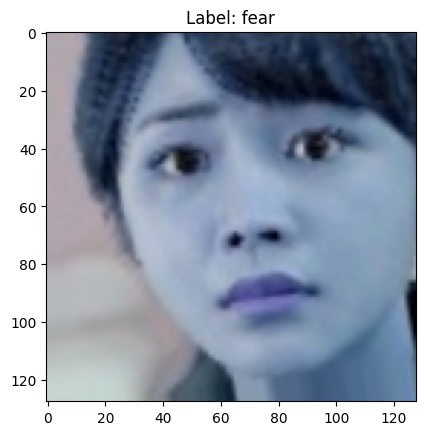

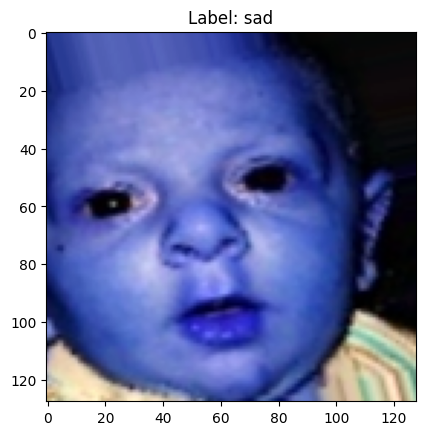

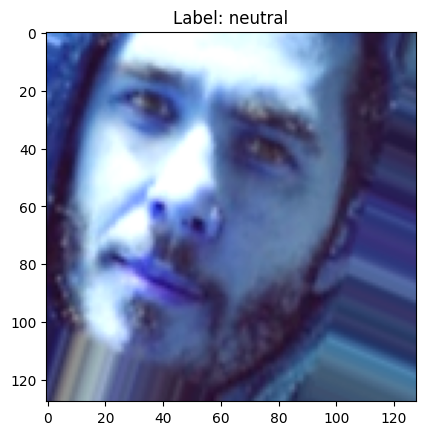

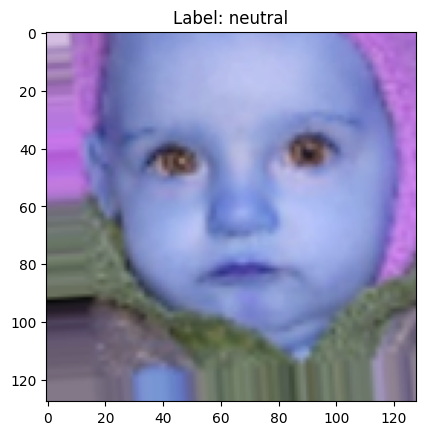

[[[0.8313726  0.74509805 0.882353  ]
  [0.8313726  0.74509805 0.882353  ]
  [0.8313726  0.74509805 0.882353  ]
  ...
  [0.6627451  0.43137258 0.81568635]
  [0.6862745  0.4431373  0.8352942 ]
  [0.6901961  0.44705886 0.8431373 ]]

 [[0.8313726  0.74509805 0.882353  ]
  [0.8313726  0.74509805 0.882353  ]
  [0.8313726  0.74509805 0.882353  ]
  ...
  [0.67058825 0.4431373  0.8235295 ]
  [0.68235296 0.44705886 0.83921576]
  [0.6745098  0.43921572 0.8431373 ]]

 [[0.8313726  0.74509805 0.882353  ]
  [0.8313726  0.74509805 0.882353  ]
  [0.8313726  0.74509805 0.882353  ]
  ...
  [0.67058825 0.4431373  0.8235295 ]
  [0.6666667  0.43529415 0.8235295 ]
  [0.654902   0.41960788 0.8196079 ]]

 ...

 [[0.5137255  0.47058827 0.53333336]
  [0.5137255  0.47058827 0.53333336]
  [0.5137255  0.47058827 0.53333336]
  ...
  [0.40784317 0.3647059  0.48627454]
  [0.4431373  0.41176474 0.5137255 ]
  [0.5411765  0.49411768 0.57254905]]

 [[0.5137255  0.47058827 0.53333336]
  [0.5137255  0.47058827 0.53333336]


In [26]:
i = 0
for images, labels in train_generator:
    # Get one image and its label from the current batch

    image = images[0]
    label = labels[0]

    # Display the image and label
    plt.imshow(image)
    plt.title(f"Label: {train_image_labelname[label]}")
    plt.show()

    # Break after visualizing one image (optional)
    if(i  >= 3):
      print(image)
      break
    else:
      i += 1


In [30]:
#Building of Model
i = Input(shape=(128,128, 3))
x = Conv2D(32,(3,3), activation = "relu", padding = "same")(i)
x = BatchNormalization()(x)

x = Conv2D(32,(3,3), activation = "relu", padding = "same")(x)
x = BatchNormalization()(x)
x = AveragePooling2D((2,2))(x)

x = Conv2D(64,(3,3), activation = "relu", padding = "same")(x)
x = BatchNormalization()(x)

x = Conv2D(64,(3,3), activation = "relu", padding = "same")(x)
x = BatchNormalization()(x)
x = AveragePooling2D((2,2))(x)

x = Conv2D(128,(3,3), activation = "relu", padding = "same")(x)
x = BatchNormalization()(x)

x = Conv2D(128,(3,3), activation = "relu", padding = "same")(x)
x = BatchNormalization()(x)
x = AveragePooling2D((2,2))(x)

x = Conv2D(256,(3,3), activation = "relu", padding = "same")(x)
x = BatchNormalization()(x)

x = Conv2D(256,(3,3), activation = "relu", padding = "same")(x)
x = BatchNormalization()(x)
x = AveragePooling2D((2,2))(x)

x = Conv2D(512,(3,3), activation = "relu", padding = "same")(x)
x = BatchNormalization()(x)

x = Conv2D(512,(3,3), activation = "relu", padding = "same")(x)
x = BatchNormalization()(x)
x = AveragePooling2D((2,2))(x)

x = Flatten()(x)
#x = Dropout(0.3)(x)
x = Dense(1024, activation='relu', kernel_regularizer='l2')(x)
x = Dropout(0.2)(x)
x = Dense(8, activation='softmax')(x) # 8 emotion classes


model = Model(i,x)

In [31]:
model.compile(loss='sparse_categorical_crossentropy',
              optimizer=Adam(learning_rate=0.001),
              metrics=['accuracy'])

lr_reducer = ReduceLROnPlateau(monitor='val_loss',
                               factor=0.3,
                               patience=2,
                               verbose=1)

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5)  # Monitor validation loss



r = model.fit(train_generator,
  #steps_per_epoch=len(train_generator),
  epochs=40,
  batch_size = 4096,
  validation_data = test_generator,
  callbacks=[lr_reducer]
)

Epoch 1/40
733/733 [==============================] - 62s 84ms/step - loss: 5.0692 - accuracy: 0.1597 - val_loss: 2.3744 - val_accuracy: 0.1549 - lr: 0.0010
Epoch 2/40
733/733 [==============================] - 86s 117ms/step - loss: 2.2049 - accuracy: 0.2603 - val_loss: 2.1459 - val_accuracy: 0.3086 - lr: 0.0010
Epoch 3/40
733/733 [==============================] - 80s 110ms/step - loss: 1.9095 - accuracy: 0.3629 - val_loss: 2.0276 - val_accuracy: 0.3186 - lr: 0.0010
Epoch 4/40
733/733 [==============================] - 65s 88ms/step - loss: 1.7480 - accuracy: 0.4193 - val_loss: 2.0857 - val_accuracy: 0.3323 - lr: 0.0010
Epoch 5/40
733/733 [==============================] - 61s 84ms/step - loss: 1.6190 - accuracy: 0.4678 - val_loss: 1.7058 - val_accuracy: 0.4548 - lr: 0.0010
Epoch 6/40
733/733 [==============================] - 61s 83ms/step - loss: 1.5196 - accuracy: 0.5029 - val_loss: 1.4825 - val_accuracy: 0.5089 - lr: 0.0010
Epoch 7/40
733/733 [==============================] - 61

In [32]:
model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 128, 128, 3)]     0         
                                                                 
 conv2d_10 (Conv2D)          (None, 128, 128, 32)      896       
                                                                 
 batch_normalization_10 (Bat  (None, 128, 128, 32)     128       
 chNormalization)                                                
                                                                 
 conv2d_11 (Conv2D)          (None, 128, 128, 32)      9248      
                                                                 
 batch_normalization_11 (Bat  (None, 128, 128, 32)     128       
 chNormalization)                                                
                                                                 
 average_pooling2d_5 (Averag  (None, 64, 64, 32)       0   

In [33]:
model.save("MSc Final Year Project.h5")

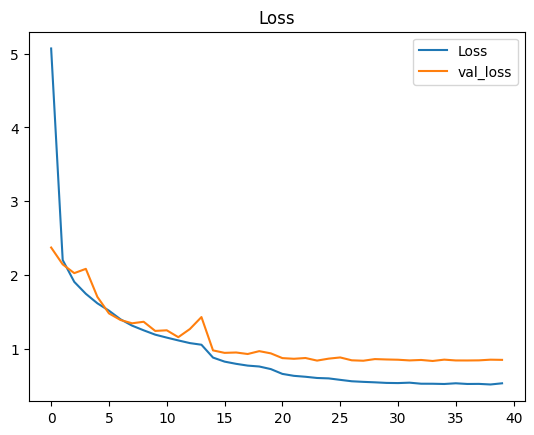

In [34]:
#Plotting Loss
plt.title("Loss")
plt.plot(r.history['loss'],label="Loss")
plt.plot(r.history['val_loss'], label = "val_loss")
plt.legend()
plt.show()

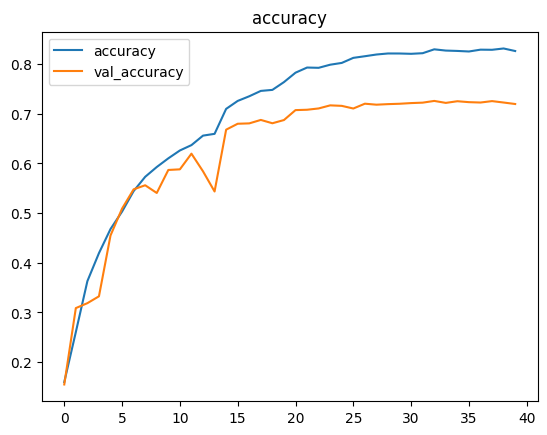

In [35]:
#Plotting Loss
plt.title("accuracy")
plt.plot(r.history['accuracy'],label="accuracy")
plt.plot(r.history['val_accuracy'], label = "val_accuracy")
plt.legend()
plt.show()

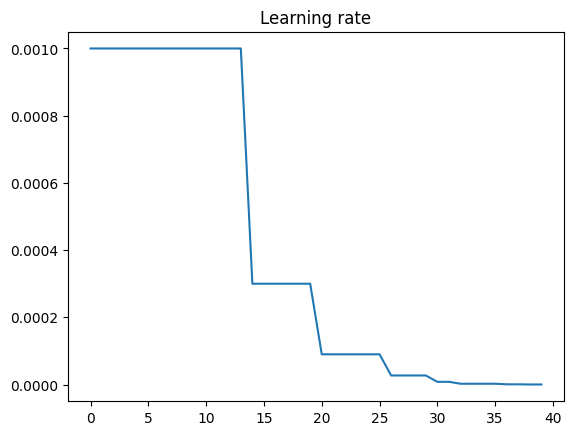

In [36]:
#Plotting Loss
plt.title("Learning rate")
plt.plot(r.history['lr'])

plt.show()

In [5]:
model = load_model("MSc Final Year Project.h5")

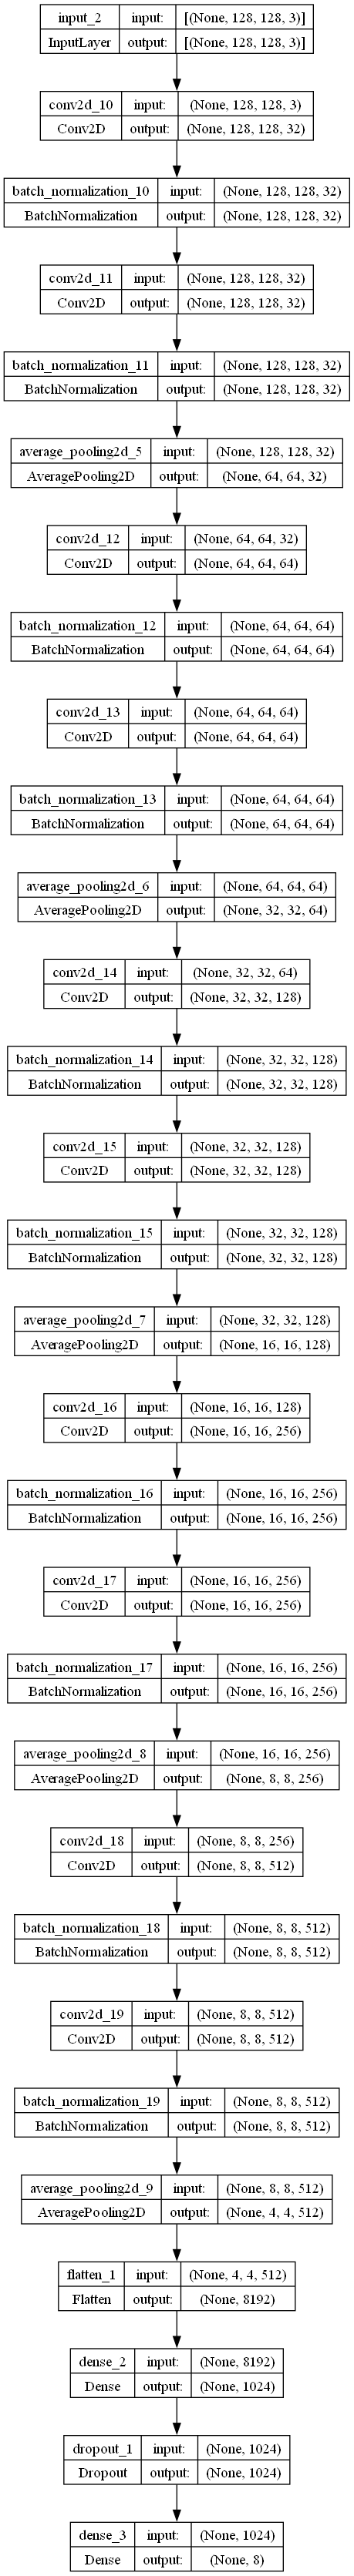

In [38]:
from tensorflow.keras.utils import plot_model
plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

In [6]:
x_obs = joblib.load("x_obs.joblib")
y_obs = joblib.load("y_obs.joblib")

In [7]:
train_image_labelname = joblib.load("train_image_labelname.joblib")

In [8]:
print(train_image_labelname)

['anger', 'contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [10]:
x_obs = x_obs/255.0
print(x_obs)

[[[[0.52156863 0.77254902 0.89411765]
   [0.50980392 0.76470588 0.88627451]
   [0.50980392 0.78431373 0.90196078]
   ...
   [0.64705882 0.87058824 0.99215686]
   [0.63137255 0.84313725 0.98039216]
   [0.6        0.81176471 0.94901961]]

  [[0.51372549 0.75294118 0.87843137]
   [0.51764706 0.76862745 0.89019608]
   [0.51764706 0.78039216 0.90196078]
   ...
   [0.62745098 0.86666667 0.99215686]
   [0.6        0.83921569 0.97254902]
   [0.57647059 0.81568627 0.94901961]]

  [[0.48235294 0.71764706 0.83529412]
   [0.49803922 0.74117647 0.85882353]
   [0.51372549 0.76470588 0.88235294]
   ...
   [0.59215686 0.86666667 0.98431373]
   [0.57254902 0.84313725 0.97254902]
   [0.54117647 0.81960784 0.94901961]]

  ...

  [[0.00392157 0.00784314 0.        ]
   [0.00392157 0.00784314 0.        ]
   [0.00392157 0.00392157 0.00392157]
   ...
   [0.00392157 0.00392157 0.00392157]
   [0.01176471 0.00392157 0.00392157]
   [0.01176471 0.00392157 0.00392157]]

  [[0.00392157 0.00784314 0.        ]
   [0.0

In [11]:
model.evaluate(x_obs,y_obs)

63/63 [==============================] - 7s 23ms/step - loss: 1.0837 - accuracy: 0.6785


[1.083663821220398, 0.6784999966621399]

In [9]:
y_pred = model.predict(x_obs)

63/63 [==============================] - 7s 21ms/step


In [16]:
print(y_pred.astype(float))
y_pred_index = []
for a in y_pred.astype(float):
   y_pred_index.append(np.argmax(a))
y_pred_index = np.array(y_pred_index)
#y_pred_index = np.argmax(y_pred)
print(y_pred_index)
print(" --- ")
print(y_obs)

[[9.99946833e-01 0.00000000e+00 3.76665898e-09 ... 0.00000000e+00
  3.39856740e-31 0.00000000e+00]
 [2.47417735e-20 1.37887016e-26 2.52832780e-24 ... 0.00000000e+00
  7.98906587e-18 1.84035582e-22]
 [2.08962313e-16 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 1.55797930e-23]
 ...
 [8.20091554e-27 2.31346436e-28 3.45822253e-27 ... 2.96631885e-31
  1.00000000e+00 0.00000000e+00]
 [7.18552064e-06 3.50558338e-07 2.01541752e-05 ... 1.03226707e-08
  2.32549355e-04 4.62167943e-03]
 [5.21246457e-12 2.12777278e-12 1.10640690e-06 ... 2.16460337e-14
  2.31706828e-01 4.04120737e-09]]
[0 3 3 ... 6 3 3]
 --- 
[0 2 0 ... 1 5 4]


In [17]:
print(y_pred.astype(float))

[[9.99946833e-01 0.00000000e+00 3.76665898e-09 ... 0.00000000e+00
  3.39856740e-31 0.00000000e+00]
 [2.47417735e-20 1.37887016e-26 2.52832780e-24 ... 0.00000000e+00
  7.98906587e-18 1.84035582e-22]
 [2.08962313e-16 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 1.55797930e-23]
 ...
 [8.20091554e-27 2.31346436e-28 3.45822253e-27 ... 2.96631885e-31
  1.00000000e+00 0.00000000e+00]
 [7.18552064e-06 3.50558338e-07 2.01541752e-05 ... 1.03226707e-08
  2.32549355e-04 4.62167943e-03]
 [5.21246457e-12 2.12777278e-12 1.10640690e-06 ... 2.16460337e-14
  2.31706828e-01 4.04120737e-09]]


In [29]:
y_pred_dec = np.around(y_pred, decimals=4)
print(y_pred_dec)

[[9.999e-01 0.000e+00 0.000e+00 ... 0.000e+00 0.000e+00 0.000e+00]
 [0.000e+00 0.000e+00 0.000e+00 ... 0.000e+00 0.000e+00 0.000e+00]
 [0.000e+00 0.000e+00 0.000e+00 ... 0.000e+00 0.000e+00 0.000e+00]
 ...
 [0.000e+00 0.000e+00 0.000e+00 ... 0.000e+00 1.000e+00 0.000e+00]
 [0.000e+00 0.000e+00 0.000e+00 ... 0.000e+00 2.000e-04 4.600e-03]
 [0.000e+00 0.000e+00 0.000e+00 ... 0.000e+00 2.317e-01 0.000e+00]]


In [ ]:
import numpy as np

# List of emotion categories
emotions = train_image_labelname

# Function to get emotion probabilities for a given image
def get_emotion_probabilities(image):
    """
    This function should return the probability scores for each emotion category
    for the given input image.
    """
    # Example output (6 categories)
    return [0.1, 0.2, 0.05, 0.3, 0.15, 0.2]

# Set the probability threshold
threshold = 0.2

# Function to analyze blended emotions
def analyze_blended_emotions(image):
    # Get emotion probabilities for the image
    probabilities = get_emotion_probabilities(image)

    # Find emotions with probabilities above the threshold
    relevant_emotions = [emotion for emotion, prob in zip(emotions, probabilities) if prob >= threshold]

    # If there are multiple relevant emotions, it's a blended emotional state
    if len(relevant_emotions) > 1:
        print(f"Blended emotional state for image: {relevant_emotions}")
        # You can perform additional analysis or visualization here
    else:
        print(f"Single emotion assignment for image: {relevant_emotions}")

# Example usage
analyze_blended_emotions('face1.jpg')
analyze_blended_emotions('face2.jpg')

In [21]:
from sklearn.metrics import classification_report

In [16]:
print(classification_report(y_obs, y_pred_index, target_names=train_image_labelname))

              precision    recall  f1-score   support

       anger       0.63      0.66      0.64       259
    contempt       0.59      0.78      0.67       250
     disgust       0.65      0.68      0.67       245
        fear       0.71      0.61      0.66       251
       happy       0.98      0.71      0.82       231
     neutral       0.97      0.57      0.72       259
         sad       0.58      0.75      0.65       246
    surprise       0.60      0.67      0.64       259

    accuracy                           0.68      2000
   macro avg       0.71      0.68      0.68      2000
weighted avg       0.71      0.68      0.68      2000



In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

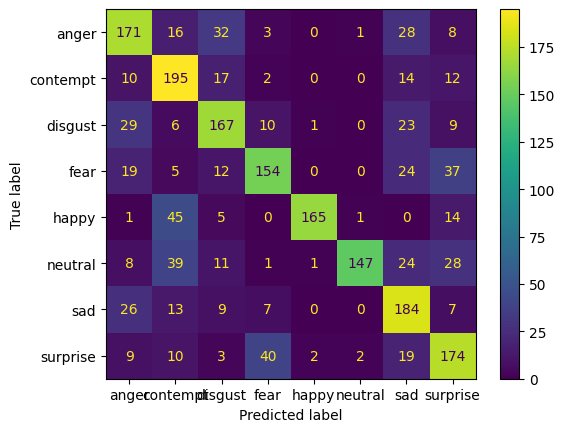

In [50]:
cm = confusion_matrix(y_obs, y_pred_index)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=train_image_labelname)
disp.plot()
plt.show()

In [17]:
from sklearn.metrics import f1_score

# Calculate micro F1 score (treats all samples as equal)
micro_f1 = f1_score(y_obs, y_pred_index, average='micro')

# Calculate macro F1 score (averages F1 score across all classes)
macro_f1 = f1_score(y_obs, y_pred_index, average='macro')

# Print the results
print("Micro F1 Score:", micro_f1)
print("Macro F1 Score:", macro_f1)

Micro F1 Score: 0.6785
Macro F1 Score: 0.6841415668402315


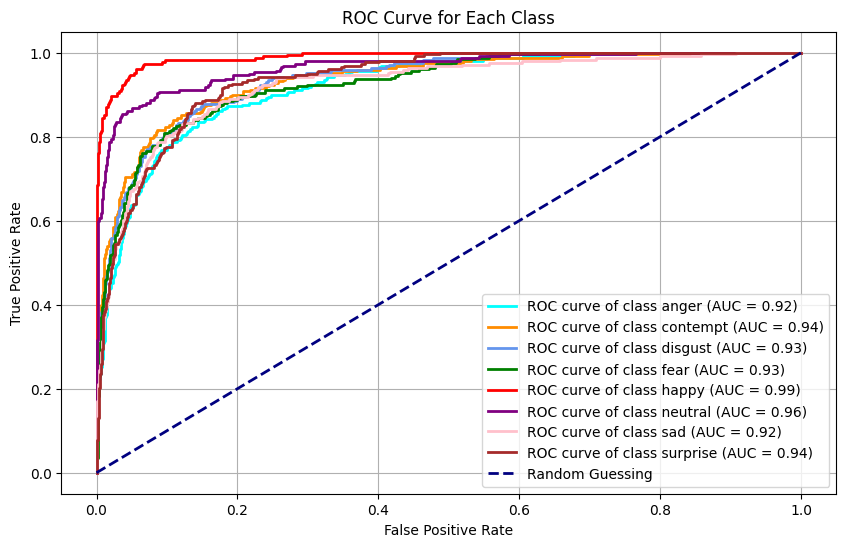

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle
#predicted_probs = np.random.rand(100, 8)
#true_labels = np.random.randint(0, 8, size=100)

# Binarize the true labels
true_labels_bin = label_binarize(y_obs, classes=np.arange(8))

# Initialize the plot
plt.figure(figsize=(10, 6))

# Set colors for each class
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 'purple', 'pink', 'brown'])

# Calculate ROC curve for each class
for i, color in zip(range(8), colors):
    fpr, tpr, _ = roc_curve(true_labels_bin[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label='ROC curve of class {0} (AUC = {1:0.2f})'.format(train_image_labelname[i], roc_auc))

# Plot ROC curve for random guessing
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing')

# Set labels and title
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Each Class')
plt.legend(loc='lower right')
plt.grid(True)

# Show the plot
plt.show()

In [8]:
t_img = cv2.imread("fer_plus/anger/fer0000010.png")

t_img = np.array(t_img)
#print(t_img)
print(t_img.shape)
print(type(t_img))

(640, 640, 3)
<class 'numpy.ndarray'>


In [9]:
print(t_img)

[[[ 31  31  31]
  [ 31  31  31]
  [ 31  31  31]
  ...
  [ 35  35  35]
  [ 35  35  35]
  [ 35  35  35]]

 [[ 31  31  31]
  [ 31  31  31]
  [ 31  31  31]
  ...
  [ 35  35  35]
  [ 35  35  35]
  [ 35  35  35]]

 [[ 31  31  31]
  [ 31  31  31]
  [ 31  31  31]
  ...
  [ 35  35  35]
  [ 35  35  35]
  [ 35  35  35]]

 ...

 [[ 32  32  32]
  [ 32  32  32]
  [ 32  32  32]
  ...
  [174 174 174]
  [174 174 174]
  [174 174 174]]

 [[ 32  32  32]
  [ 32  32  32]
  [ 32  32  32]
  ...
  [174 174 174]
  [174 174 174]
  [174 174 174]]

 [[ 32  32  32]
  [ 32  32  32]
  [ 32  32  32]
  ...
  [174 174 174]
  [174 174 174]
  [174 174 174]]]


In [36]:
!mkdir "temp"

A subdirectory or file temp already exists.


In [22]:
i = 0

test_image = []
test_image_label = []
current_label = ""
for dir in os.listdir("fer_plus"):
  print(dir)
  if dir != ".DS_Store":
    for filename in os.listdir("fer_plus/"+dir):
      if filename != ".DS_Store":
        #print(filename)
        
        for n in range(len(train_image_labelname)):
          if dir.replace(" ","") == train_image_labelname[n].replace(" ",""):
            test_image_label.append(n)
            image = cv2.resize(cv2.imread("fer_plus/"+dir+"/"+filename), (128, 128))
            cv2.imwrite("temp/temp.jpg", image, [cv2.IMWRITE_JPEG_QUALITY, 95])
            image = cv2.imread('temp/temp.jpg')
            test_image.append(image)
            current_label = train_image_labelname[n]
            break
    print("done loading ",current_label)
       


anger
done loading  anger
contempt
done loading  contempt
disgust
done loading  disgust
fear
done loading  fear
happy
done loading  happy
neutral
done loading  neutral
sad
done loading  sad
surprise
done loading  surprise


In [23]:
print(test_image_label[1])

0


In [24]:
test_image = np.array(test_image)
test_image_label = np.array(test_image_label)

In [25]:
print(test_image.shape)
print(test_image_label.shape)

(35710, 128, 128, 3)
(35710,)


In [26]:
test_image = test_image/255.0

In [27]:
print(test_image[0])

[[[0.12156863 0.12156863 0.12156863]
  [0.11764706 0.11764706 0.11764706]
  [0.11372549 0.11372549 0.11372549]
  ...
  [0.15686275 0.15686275 0.15686275]
  [0.14901961 0.14901961 0.14901961]
  [0.1372549  0.1372549  0.1372549 ]]

 [[0.12156863 0.12156863 0.12156863]
  [0.11764706 0.11764706 0.11764706]
  [0.10980392 0.10980392 0.10980392]
  ...
  [0.15686275 0.15686275 0.15686275]
  [0.14901961 0.14901961 0.14901961]
  [0.14117647 0.14117647 0.14117647]]

 [[0.1254902  0.1254902  0.1254902 ]
  [0.12156863 0.12156863 0.12156863]
  [0.10980392 0.10980392 0.10980392]
  ...
  [0.15294118 0.15294118 0.15294118]
  [0.15294118 0.15294118 0.15294118]
  [0.14509804 0.14509804 0.14509804]]

 ...

 [[0.12156863 0.12156863 0.12156863]
  [0.12156863 0.12156863 0.12156863]
  [0.11764706 0.11764706 0.11764706]
  ...
  [0.66666667 0.66666667 0.66666667]
  [0.67058824 0.67058824 0.67058824]
  [0.6745098  0.6745098  0.6745098 ]]

 [[0.1254902  0.1254902  0.1254902 ]
  [0.1254902  0.1254902  0.1254902 ]


In [28]:
x_test, x_test1, y_test, y_test1 = train_test_split(test_image, test_image_label, test_size=0.5, random_state=42)

In [29]:
joblib.dump(x_test,"x_test.joblib")
joblib.dump(x_test1,"x_test1.joblib")
joblib.dump(y_test,"y_test.joblib")
joblib.dump(y_test1,"y_test1.joblib")

['y_test1.joblib']

In [7]:
x_test, x_test1, y_test, y_test1 = joblib.load("x_test.joblib"),joblib.load("x_test1.joblib"),joblib.load("y_test.joblib"),joblib.load("y_test1.joblib")

In [8]:
print(x_test.shape)
print(x_test1.shape)

print(y_test.shape)
print(y_test1.shape)

(17855, 128, 128, 3)
(17855, 128, 128, 3)
(17855,)
(17855,)


In [31]:
y_pred = model.predict(x_test)


558/558 [==============================] - 11s 18ms/step


In [32]:
joblib.dump(y_pred,"y_pred.joblib")

['y_pred.joblib']

In [9]:
y_pred1 = model.predict(x_test1) 

558/558 [==============================] - 15s 17ms/step


In [10]:
joblib.dump(y_pred1,"y_pred1.joblib")

['y_pred1.joblib']

In [11]:
print(y_pred1)

[[6.8468384e-05 5.1785421e-05 6.8864797e-06 ... 9.9895871e-01
  7.5374258e-04 1.4341444e-04]
 [1.8143318e-06 3.3797809e-07 5.9680175e-08 ... 1.3007496e-05
  6.8863675e-09 9.9844486e-01]
 [1.1973587e-03 3.0919735e-03 1.5228031e-03 ... 9.7991699e-01
  7.5865556e-03 4.3747989e-03]
 ...
 [7.8785974e-01 1.3363585e-05 1.8397997e-04 ... 1.4444835e-07
  2.4788761e-07 6.7722257e-03]
 [3.6629339e-04 1.5842387e-03 2.7806705e-04 ... 8.6836956e-02
  5.1124732e-04 8.8893551e-01]
 [2.5595541e-04 3.9037733e-04 8.3891377e-05 ... 4.4047423e-02
  9.9960947e-05 9.3544596e-01]]


In [43]:
y_pred, y_pred1 = joblib.load("y_pred.joblib"),joblib.load("y_pred1.joblib")

In [44]:
print(y_pred.shape)
print(y_pred1.shape)

(17855, 8)
(17855, 8)


In [45]:
y_pred = np.concatenate([y_pred,y_pred1])

In [46]:
print(y_pred.shape)

(35710, 8)


In [47]:
x_test = np.concatenate([x_test,x_test1])
y_test = np.concatenate([y_test,y_test1])

In [48]:
print(y_pred)

[[7.8226485e-08 5.6299473e-06 1.9962037e-08 ... 3.1460091e-02
  5.8647853e-08 9.6818697e-01]
 [7.8040175e-02 4.2156648e-02 2.1807490e-02 ... 3.7442175e-01
  2.3260929e-01 8.7092184e-02]
 [7.3876362e-03 5.1577725e-02 3.0345470e-02 ... 5.2225512e-02
  5.1770462e-03 8.1398459e-03]
 ...
 [7.8785974e-01 1.3363585e-05 1.8397997e-04 ... 1.4444835e-07
  2.4788761e-07 6.7722257e-03]
 [3.6629339e-04 1.5842387e-03 2.7806705e-04 ... 8.6836956e-02
  5.1124732e-04 8.8893551e-01]
 [2.5595541e-04 3.9037733e-04 8.3891377e-05 ... 4.4047423e-02
  9.9960947e-05 9.3544596e-01]]


In [18]:
print(y_pred.astype(float))
y_pred_index = []
for a in y_pred.astype(float):
   y_pred_index.append(np.argmax(a))
y_pred_index = np.array(y_pred_index)
#y_pred_index = np.argmax(y_pred)
print(y_pred_index)
print(" --- ")
print(y_test)

[[7.82264848e-08 5.62994728e-06 1.99620374e-08 ... 3.14600915e-02
  5.86478528e-08 9.68186975e-01]
 [7.80401751e-02 4.21566479e-02 2.18074899e-02 ... 3.74421746e-01
  2.32609287e-01 8.70921835e-02]
 [7.38763623e-03 5.15777245e-02 3.03454697e-02 ... 5.22255115e-02
  5.17704617e-03 8.13984592e-03]
 ...
 [7.87859738e-01 1.33635849e-05 1.83979966e-04 ... 1.44448350e-07
  2.47887613e-07 6.77222572e-03]
 [3.66293389e-04 1.58423872e-03 2.78067047e-04 ... 8.68369564e-02
  5.11247315e-04 8.88935506e-01]
 [2.55955412e-04 3.90377332e-04 8.38913766e-05 ... 4.40474227e-02
  9.99609474e-05 9.35445964e-01]]
[7 5 4 ... 0 7 7]
 --- 
[7 6 4 ... 0 7 3]


In [24]:
print(classification_report(y_test, y_pred_index, target_names=train_image_labelname))

              precision    recall  f1-score   support

       anger       0.51      0.31      0.39      3124
    contempt       0.02      0.04      0.03       227
     disgust       0.10      0.56      0.16       250
        fear       0.20      0.44      0.27       829
       happy       0.84      0.83      0.84      9365
     neutral       0.73      0.77      0.75     12994
         sad       0.60      0.22      0.32      4427
    surprise       0.62      0.77      0.69      4494

    accuracy                           0.66     35710
   macro avg       0.45      0.49      0.43     35710
weighted avg       0.69      0.66      0.66     35710



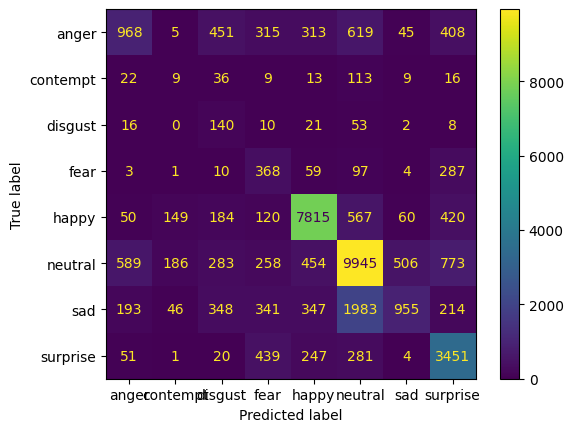

In [25]:
cm = confusion_matrix(y_test, y_pred_index)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=train_image_labelname)
disp.plot()
plt.show()

In [27]:
from sklearn.metrics import f1_score

# Calculate micro F1 score (treats all samples as equal)
micro_f1 = f1_score(y_test, y_pred_index, average='micro')

# Calculate macro F1 score (averages F1 score across all classes)
macro_f1 = f1_score(y_test, y_pred_index, average='macro')

# Print the results
print("Micro F1 Score:", micro_f1)
print("Macro F1 Score:", macro_f1)

Micro F1 Score: 0.6623074768972277
Macro F1 Score: 0.42990340277361966


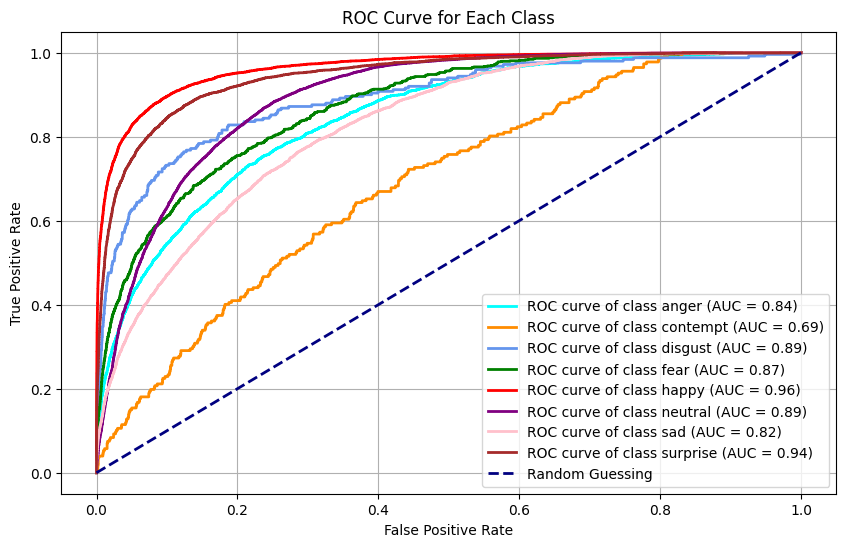

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle
#predicted_probs = np.random.rand(100, 8)
#true_labels = np.random.randint(0, 8, size=100)

# Binarize the true labels
true_labels_bin = label_binarize(y_test, classes=np.arange(8))

# Initialize the plot
plt.figure(figsize=(10, 6))

# Set colors for each class
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 'purple', 'pink', 'brown'])

# Calculate ROC curve for each class
for i, color in zip(range(8), colors):
    fpr, tpr, _ = roc_curve(true_labels_bin[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label='ROC curve of class {0} (AUC = {1:0.2f})'.format(train_image_labelname[i], roc_auc))

# Plot ROC curve for random guessing
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing')

# Set labels and title
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Each Class')
plt.legend(loc='lower right')
plt.grid(True)

# Show the plot
plt.show()

Analysing of blended emotions on images

In [66]:
t_img = cv2.resize(cv2.imread("a3.jpg"), (128, 128))
t_img = np.array(t_img)
t_img = t_img / 255.0
print(t_img)

print(type(t_img))

[[[1.         1.         1.        ]
  [0.01568627 0.         0.00392157]
  [0.01960784 0.00392157 0.        ]
  ...
  [0.03137255 0.01176471 0.        ]
  [0.01960784 0.00392157 0.        ]
  [0.01960784 0.00392157 0.        ]]

 [[1.         1.         1.        ]
  [0.01568627 0.         0.        ]
  [0.02352941 0.01176471 0.        ]
  ...
  [0.03137255 0.01176471 0.        ]
  [0.02745098 0.01176471 0.00392157]
  [0.01960784 0.00392157 0.        ]]

 [[1.         1.         1.        ]
  [0.02352941 0.00784314 0.00392157]
  [0.05098039 0.03529412 0.01568627]
  ...
  [0.03529412 0.01568627 0.00392157]
  [0.02745098 0.01568627 0.        ]
  [0.02352941 0.01176471 0.        ]]

 ...

 [[1.         1.         1.        ]
  [0.02745098 0.00784314 0.00392157]
  [0.02352941 0.00784314 0.00392157]
  ...
  [0.02352941 0.00784314 0.00392157]
  [0.02352941 0.00784314 0.00392157]
  [0.01960784 0.00392157 0.        ]]

 [[1.         1.         1.        ]
  [0.02352941 0.00784314 0.00392157]


In [67]:
t_img = np.expand_dims(t_img, axis=0) 


In [68]:
t_img.shape

(1, 128, 128, 3)

In [69]:
y_pred = model.predict(t_img)
print(y_pred)

1/1 [==============================] - 0s 18ms/step
[[2.6173051e-02 7.1953731e-03 2.1232111e-02 3.8065571e-01 9.5840449e-05
  1.3002047e-03 5.4262662e-01 2.0721048e-02]]


In [70]:
y_pred_dec = np.around(y_pred, decimals=3)
print(y_pred_dec)

[[0.026 0.007 0.021 0.381 0.    0.001 0.543 0.021]]


In [ ]:
import decimal

def convert_scientific_to_decimal(sci_notation):
  """Converts a string in scientific notation to a regular decimal string."""

  parts = sci_notation.split('e')
  mantissa, exponent = parts[0], int(parts[1])

  # Use decimal.Decimal to handle arbitrary precision
  decimal_value = decimal.Decimal(mantissa) * 10**exponent

  # Return a formatted string with 2 decimal places
  return f"{decimal_value:.2f}"

# Example usage

decimal_numbers = [convert_scientific_to_decimal(num) for num in y_pred]
print(decimal_numbers)

In [50]:
import numpy as np

# Assuming you have your image data with predicted category probabilities
# (like the example in your previous question)
image_data = y_pred.astype(float)  # Your image data with probabilities

# Get the number of images and categories
num_images, num_categories = image_data.shape

# Find the most likely category for each image
predicted_categories = np.argmax(image_data, axis=1)

# Identify categories with high probability (e.g., > 0.2)
high_prob_categories = np.where(np.mean(image_data, axis=0) > 0.2)[0]

# Co-occurrence matrix for high probability categories
co_occurrence_matrix = np.zeros((len(high_prob_categories), len(high_prob_categories)))

# Count co-occurrences in predicted categories
for image_idx in range(num_images):
  for cat_idx1 in high_prob_categories:
    if image_data[image_idx, cat_idx1] > 0.2:
      for cat_idx2 in high_prob_categories:
        if image_idx != cat_idx1 and image_data[image_idx, cat_idx2] > 0.2:
          co_occurrence_matrix[cat_idx1, cat_idx2] += 1

# Analyze the co-occurrence matrix (e.g., using heatmaps or further calculations)


IndexError: index 5 is out of bounds for axis 0 with size 2

##AffectNet DataSet to evaluate model

In [22]:
i = 0
dir_locate = "affectnet"
test_image = []
test_image_label = []
current_label = ""
for dir in os.listdir(dir_locate):
  print(dir)
  if dir != ".DS_Store":
    for filename in os.listdir(dir_locate+"/"+dir):
      if filename != ".DS_Store":
        #print(filename)
        
        for n in range(len(train_image_labelname)):
          if dir.replace(" ","") == train_image_labelname[n].replace(" ",""):
            test_image_label.append(n)
            image = cv2.resize(cv2.imread(dir_locate+"/"+dir+"/"+filename), (128, 128))
            cv2.imwrite("temp/temp.jpg", image, [cv2.IMWRITE_JPEG_QUALITY, 95])
            image = cv2.imread('temp/temp.jpg')
            test_image.append(image)
            current_label = train_image_labelname[n]
            break
    print("done loading ",current_label)

anger
done loading  anger
contempt
done loading  contempt
disgust
done loading  disgust
fear
done loading  fear
happy
done loading  happy
neutral
done loading  neutral
sad
done loading  sad
surprise
done loading  surprise


In [23]:
test_image = np.array(test_image)
test_image_label = np.array(test_image_label)

In [24]:
print(test_image.shape)
print(test_image_label.shape)

(29042, 128, 128, 3)
(29042,)


In [25]:
test_image = test_image/255.0

In [26]:
print(test_image[0])

[[[0.23529412 0.27843137 0.36470588]
  [0.23137255 0.2745098  0.35294118]
  [0.22745098 0.2627451  0.34117647]
  ...
  [0.22352941 0.18039216 0.16470588]
  [0.22352941 0.18039216 0.16470588]
  [0.22745098 0.18431373 0.16862745]]

 [[0.23137255 0.2745098  0.36078431]
  [0.23529412 0.27058824 0.34901961]
  [0.22352941 0.2627451  0.33333333]
  ...
  [0.21568627 0.17254902 0.15686275]
  [0.21568627 0.17254902 0.15686275]
  [0.21960784 0.17647059 0.16078431]]

 [[0.23529412 0.27058824 0.34901961]
  [0.23137255 0.27058824 0.34117647]
  [0.22745098 0.25882353 0.3254902 ]
  ...
  [0.20784314 0.16470588 0.14901961]
  [0.21176471 0.16862745 0.15294118]
  [0.21176471 0.16862745 0.15294118]]

 ...

 [[0.11764706 0.08235294 0.07058824]
  [0.11764706 0.08235294 0.07058824]
  [0.11764706 0.08235294 0.07058824]
  ...
  [0.17254902 0.1372549  0.12156863]
  [0.18039216 0.1372549  0.12156863]
  [0.17254902 0.12941176 0.11372549]]

 [[0.11372549 0.07843137 0.06666667]
  [0.11764706 0.08235294 0.07058824]


In [27]:
x_test, x_test1, y_test, y_test1 = train_test_split(test_image, test_image_label, test_size=0.5, random_state=42)

In [28]:
joblib.dump(x_test,"x_test.joblib")
joblib.dump(x_test1,"x_test1.joblib")
joblib.dump(y_test,"y_test.joblib")
joblib.dump(y_test1,"y_test1.joblib")

['y_test1.joblib']

In [6]:
x_test, x_test1, y_test, y_test1 = joblib.load("x_test.joblib"),joblib.load("x_test1.joblib"),joblib.load("y_test.joblib"),joblib.load("y_test1.joblib")

In [29]:
print(x_test.shape)
print(x_test1.shape)

print(y_test.shape)
print(y_test1.shape)

(14521, 128, 128, 3)
(14521, 128, 128, 3)
(14521,)
(14521,)


In [30]:
y_pred = model.predict(x_test)


454/454 [==============================] - 15s 16ms/step


In [31]:
joblib.dump(y_pred,"y_pred.joblib")

['y_pred.joblib']

In [7]:
y_pred1 = model.predict(x_test1) 

454/454 [==============================] - 13s 16ms/step


In [8]:
joblib.dump(y_pred1,"y_pred1.joblib")

['y_pred1.joblib']

In [9]:
print(y_pred1.shape)

(14521, 8)


In [10]:
y_pred, y_pred1 = joblib.load("y_pred.joblib"),joblib.load("y_pred1.joblib")

In [11]:
y_pred = np.concatenate([y_pred,y_pred1])

In [13]:
print(y_pred.shape)

(29042, 8)


In [12]:
x_test = np.concatenate([x_test,x_test1])
y_test = np.concatenate([y_test,y_test1])

In [14]:
print(x_test.shape)

(29042, 128, 128, 3)


In [18]:
print(y_pred.astype(float))
y_pred_index = []
for a in y_pred.astype(float):
   y_pred_index.append(np.argmax(a))
y_pred_index = np.array(y_pred_index)
#y_pred_index = np.argmax(y_pred)
print(y_pred_index)
print(" --- ")
print(y_test)

[[4.55321670e-02 1.64531142e-01 1.18689708e-01 ... 1.63885783e-02
  4.00914028e-02 3.66815299e-01]
 [9.76954922e-02 6.88655600e-02 7.99479842e-01 ... 6.60310383e-04
  6.98859897e-03 1.69247221e-02]
 [1.46889500e-02 3.29951569e-02 2.56019365e-02 ... 4.20335773e-03
  6.37646616e-01 1.32262439e-01]
 ...
 [5.16419252e-03 2.95218383e-03 4.46399022e-03 ... 1.89309852e-04
  1.86306592e-02 9.22131315e-02]
 [8.42828676e-03 1.04817469e-03 1.98026397e-03 ... 2.92055513e-04
  3.72333499e-03 8.13937843e-01]
 [8.00491218e-03 5.33411801e-02 9.35127378e-01 ... 2.60808192e-05
  4.12561902e-04 6.92443515e-04]]
[7 2 6 ... 3 7 2]
 --- 
[4 2 6 ... 6 7 2]


In [21]:
print(classification_report(y_test, y_pred_index, target_names=train_image_labelname))

              precision    recall  f1-score   support

       anger       0.42      0.59      0.49      3218
    contempt       0.32      0.66      0.43      2871
     disgust       0.44      0.47      0.45      2477
        fear       0.47      0.54      0.50      3176
       happy       0.99      0.06      0.12      5044
     neutral       0.87      0.04      0.08      5126
         sad       0.42      0.63      0.51      3091
    surprise       0.39      0.68      0.49      4039

    accuracy                           0.41     29042
   macro avg       0.54      0.46      0.38     29042
weighted avg       0.59      0.41      0.35     29042



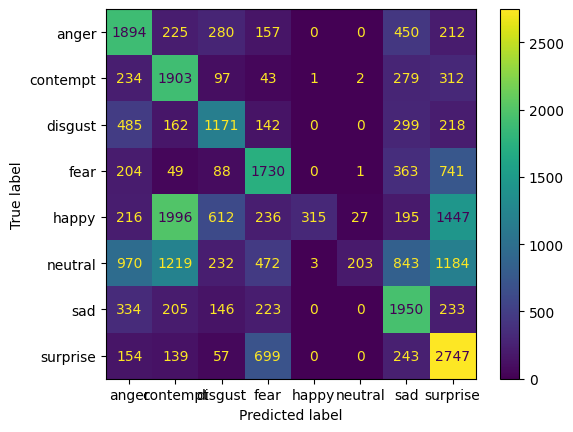

In [22]:
cm = confusion_matrix(y_test, y_pred_index)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=train_image_labelname)
disp.plot()
plt.show()

In [ ]:
#Analysing blended images

In [3]:
from graphviz import Digraph

def create_cnn_architecture():
    dot = Digraph(comment='CNN Architecture')
    dot.attr(rankdir='LR', size='14,10', dpi='300')
    
    dot.attr('node', shape='box', style='filled', color='grey', fontname='Arial', fontsize='10')
    
    with dot.subgraph(name='cluster_0') as c:
        c.attr(label='Input Layers and First group')
        c.node('input', 'Input\n(128, 128, 3)')
        c.node('conv1', 'Conv2D\n32 filters\n(None, 128, 128, 32)')
        c.node('bn1', 'BatchNorm\n(None, 128, 128, 32)')
        c.node('conv2', 'Conv2D\n32 filters\n(None, 128, 128, 32)')
        c.node('bn2', 'BatchNorm\n(None, 128, 128, 32)')
        c.node('pool1', 'AvgPool2D\n(None, 64, 64, 32)')

    with dot.subgraph(name='cluster_1') as c:
        c.attr(label='Second group')
        c.node('conv3', 'Conv2D\n64 filters\n(None, 64, 64, 64)')
        c.node('bn3', 'BatchNorm\n(None, 64, 64, 64)')
        c.node('conv4', 'Conv2D\n64 filters\n(None, 64, 64, 64)')
        c.node('bn4', 'BatchNorm\n(None, 64, 64, 64)')
        c.node('pool2', 'AvgPool2D\n(None, 32, 32, 64)')
        c.node('conv5', 'Conv2D\n128 filters\n(None, 32, 32, 128)')
        c.node('bn5', 'BatchNorm\n(None, 32, 32, 128)')

    with dot.subgraph(name='cluster_2') as c:
        c.attr(label='Third group')
        c.node('conv6', 'Conv2D\n128 filters\n(None, 32, 32, 128)')
        c.node('bn6', 'BatchNorm\n(None, 32, 32, 128)')
        c.node('pool3', 'AvgPool2D\n(None, 16, 16, 128)')
        c.node('conv7', 'Conv2D\n256 filters\n(None, 16, 16, 256)')
        c.node('bn7', 'BatchNorm\n(None, 16, 16, 256)')
        c.node('conv8', 'Conv2D\n256 filters\n(None, 16, 16, 256)')
        c.node('bn8', 'BatchNorm\n(None, 16, 16, 256)')

    with dot.subgraph(name='cluster_3') as c:
        c.attr(label='Final group')
        c.node('pool4', 'AvgPool2D\n(None, 8, 8, 256)')
        c.node('conv9', 'Conv2D\n512 filters\n(None, 8, 8, 512)')
        c.node('bn9', 'BatchNorm\n(None, 8, 8, 512)')
        c.node('pool5', 'AvgPool2D\n(None, 4, 4, 512)')
        c.node('flatten', 'Flatten\n(None, 8192)')
        c.node('dense1', 'Dense\n1024 units\n(None, 1024)')
        c.node('dropout', 'Dropout\n(None, 1024)')
        c.node('dense2', 'Dense\n8 units\n(None, 8)')
        c.node('output', 'Output\n(None, 8)')

    # Connect nodes
    nodes = ['input', 'conv1', 'bn1', 'conv2', 'bn2', 'pool1', 'conv3', 'bn3', 'conv4', 'bn4', 'pool2', 
             'conv5', 'bn5', 'conv6', 'bn6', 'pool3', 'conv7', 'bn7', 'conv8', 'bn8', 'pool4', 'conv9', 
             'bn9', 'pool5', 'flatten', 'dense1', 'dropout', 'dense2', 'output']
    
    for i in range(len(nodes) - 1):
        dot.edge(nodes[i], nodes[i+1])

    return dot

# Generate the diagram
cnn_diagram = create_cnn_architecture()
cnn_diagram.render('cnn_architecture', format='png', cleanup=True)
print("CNN architecture image has been generated as 'cnn_architecture.png'")

CNN architecture image has been generated as 'cnn_architecture.png'
